<h1 style="text-align:center; font-size:42px; margin-top:40px;">

Analyse exploratoire – Tendances des langages de programmation (Survey 2024)

</h1>

## 1. Contexte et objectif

Ce module explore les tendances d’utilisation, de préférence et d’admiration des langages de programmation à partir du dataset nettoyé du Stack Overflow Developer Survey 2024.

L’analyse se concentre sur trois axes :

- les langages **réellement utilisés** (`LanguageHaveWorkedWith`) ;
- les langages que les développeurs **souhaitent utiliser** (`LanguageWantToWorkWith`) ;
- les langages **admirés** (`LanguageAdmired`).

Ainsi que des analyses croisées :

- par pays,
- par niveau d'expérience,
- par statut (Employed, Student, Retired, Independent),
- et un focus sur les **langages les mieux rémunérés**.

Les résultats servent de base au storytelling final sur les tendances technologiques et le marché du travail.

## 2. Librairies & chargement des données

In [1]:
## 2. Librairies & chargement des données

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# Chargement du dataset final
df = pd.read_csv("../Data/Survey/processed/survey-data_V3_final.csv")

# Nombre de répondants (pour les %)
nb_repondants = df["ResponseId"].nunique()
print("Nombre de répondants :", nb_repondants)


Nombre de répondants : 61201


## 3. Aperçu des données

On vérifie rapidement la structure des données utilisées dans ce notebook.

In [2]:
# 3.1. Aperçu des premières lignes
df.head()

,ResponseId,MainBranch,Age,RemoteWork,Country,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,...,NEWCollabToolsHaveWorkedWith,AIToolCurrently Using,Country_valide,ExperienceLevel,Employed,Student,full_time,Independent,looking_for_work,Retired
0,1,I am a developer by profession,Under 18 years old,Remote,United States of America,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,...,NaN,NaN,True,junior,1,0,1,0,0,0
1,2,I am a developer by profession,35-44 years old,Remote,United Kingdom of Great Britain and Northern I...,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,...,PyCharm;Visual Studio Code;WebStorm,NaN,True,sénior,1,0,1,0,0,0
2,3,I am a developer by profession,45-54 years old,Remote,United Kingdom of Great Britain and Northern I...,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,...,Visual Studio,NaN,True,sénior,1,0,1,0,0,0
3,4,I am learning to code,18-24 years old,"Hybrid (some remote, some in-person)",Canada,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,NaN,...,NaN,Learning about a codebase;Project planning;Wri...,True,junior,0,1,1,0,0,0
4,5,I am a developer by profession,18-24 years old,"Hybrid (some remote, some in-person)",Norway,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,API document(s) and/or SDK document(s);User gu...,...,Vim,NaN,True,junior,0,1,1,0,0,0


In [3]:
# 3.2. Liste des colonnes
df.columns

Index(['ResponseId', 'MainBranch', 'Age', 'RemoteWork', 'Country',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize',
       'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse',
       'ConvertedCompYearly', 'Currency', 'LanguageHaveWorkedWith',
       'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith',
       'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith',
       'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith',
       'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith',
       'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith',
       'MiscTechWantToWorkWith', 'MiscTechAdmired', 'SOVisitFreq', 'SOAccount',
       'SOPartFreq', 'AISelect', 'AIBen', 'AIChallenges', 'JobSat', 'Industry',
       'OpSysProfessional use', 'NEWCollabToolsHaveWorkedWith',
       'AIToolCurrently Using', 'Country_

## 4. Langages utilisés (LanguageHaveWorkedWith)

Dans cette section, on analyse les langages **effectivement utilisés** par les développeurs.


### 4.1. Préparation des données : sélection + explosion des langages utilisés

In [4]:
cols_used = [
    "ResponseId", "Country", "Age", "Industry", "ExperienceLevel",
    "Employed", "Student", "Retired", "Independent",
    "ConvertedCompYearly", "LanguageHaveWorkedWith"
]

df_lang = (
    df[cols_used]
    .dropna(subset=["LanguageHaveWorkedWith"])
    .copy()
)

df_lang["LanguageHaveWorkedWith"] = df_lang["LanguageHaveWorkedWith"].str.split(";")
df_lang = df_lang.explode("LanguageHaveWorkedWith")
df_lang["LanguageHaveWorkedWith"] = df_lang["LanguageHaveWorkedWith"].str.strip()
df_lang.reset_index(drop=True, inplace=True)

df_lang.head()


,ResponseId,Country,Age,Industry,ExperienceLevel,Employed,Student,Retired,Independent,ConvertedCompYearly,LanguageHaveWorkedWith
0,2,United Kingdom of Great Britain and Northern I...,35-44 years old,Unknown,sénior,1,0,0,0,98378.962611,Bash/Shell (all shells)
1,2,United Kingdom of Great Britain and Northern I...,35-44 years old,Unknown,sénior,1,0,0,0,98378.962611,Go
2,2,United Kingdom of Great Britain and Northern I...,35-44 years old,Unknown,sénior,1,0,0,0,98378.962611,HTML/CSS
3,2,United Kingdom of Great Britain and Northern I...,35-44 years old,Unknown,sénior,1,0,0,0,98378.962611,Java
4,2,United Kingdom of Great Britain and Northern I...,35-44 years old,Unknown,sénior,1,0,0,0,98378.962611,JavaScript


### 4.2. Top 10 des langages les plus utilisés

In [5]:
dt_langage = (
    df_lang["LanguageHaveWorkedWith"]
    .value_counts()
    .head(10) * 100 / nb_repondants
).round(2)

dt_langage

LanguageHaveWorkedWith
JavaScript                 59.11
HTML/CSS                   50.06
SQL                        48.75
Python                     48.15
TypeScript                 36.80
Bash/Shell (all shells)    32.51
Java                       28.45
C#                         25.90
C++                        21.46
C                          18.86
Name: count, dtype: float64

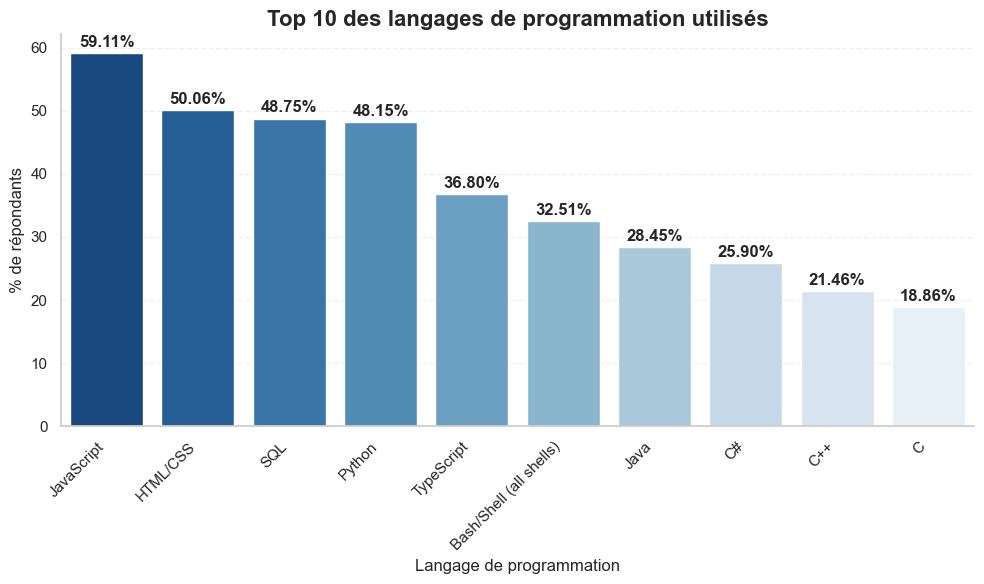

In [6]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=dt_langage.index,
    y=dt_langage.values,
    palette="Blues_r",
    hue=dt_langage.index
)

for i, v in enumerate(dt_langage.values):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center", va="bottom", fontweight="bold")

plt.title("Top 10 des langages de programmation utilisés", fontsize=16, fontweight="bold")
plt.xlabel("Langage de programmation")
plt.ylabel("% de répondants")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Languages/08_languages_top10_used.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

JavaScript, Python, SQL et HTML/CSS dominent massivement, confirmant leur rôle clé dans :
- le développement web,
- l’analyse de données,
- le backend,
- l’enseignement.

Ce socle forme le « kit de base » de la plupart des développeurs actuels.


### 4.3. Langage dominant par secteur (Industry)

In [7]:
# On repart de df_lang qui contient déjà ResponseId, Industry, LanguageHaveWorkedWith
df_ind = (
    df_lang[["ResponseId", "Industry", "LanguageHaveWorkedWith"]]
    .dropna(subset=["Industry", "LanguageHaveWorkedWith"])
    .copy()
)

# 1) Nombre de développeurs par langage et secteur (développeurs uniques)
top_lang_by_industry = (
    df_ind
    .groupby(["Industry", "LanguageHaveWorkedWith"])["ResponseId"]
    .nunique()
    .reset_index(name="count_devs")
)

# 2) Nombre total de développeurs par secteur
industry_totals = (
    df_ind
    .groupby("Industry")["ResponseId"]
    .nunique()
    .reset_index(name="total_devs_industry")
)

# 3) Merge + calcul du pourcentage
top_lang_by_industry = top_lang_by_industry.merge(industry_totals, on="Industry", how="left")
top_lang_by_industry["pct_devs"] = (
    top_lang_by_industry["count_devs"] / top_lang_by_industry["total_devs_industry"] * 100
).round(2)

# Sélection du langage dominant par secteur (en % de développeurs)
dominant_lang_pct = (
    top_lang_by_industry
    .sort_values(["Industry", "pct_devs"], ascending=[True, False])
    .groupby("Industry")
    .first()          # garde la ligne avec le % max
    .reset_index()
)

dominant_lang_pct_sorted = dominant_lang_pct.sort_values("pct_devs", ascending=False)
dominant_lang_pct_sorted[["Industry","LanguageHaveWorkedWith","pct_devs"]].head(15)




,Industry,LanguageHaveWorkedWith,pct_devs
6,Higher Education,Python,67.42
4,Government,JavaScript,67.40
13,Software Development,JavaScript,67.16
7,Insurance,JavaScript,66.84
10,Media & Advertising Services,JavaScript,66.25
12,Retail and Consumer Services,JavaScript,65.16
1,Computer Systems Design and Services,Python,63.72
5,Healthcare,JavaScript,63.41
3,Fintech,JavaScript,62.88
14,"Transportation, or Supply Chain",JavaScript,62.19


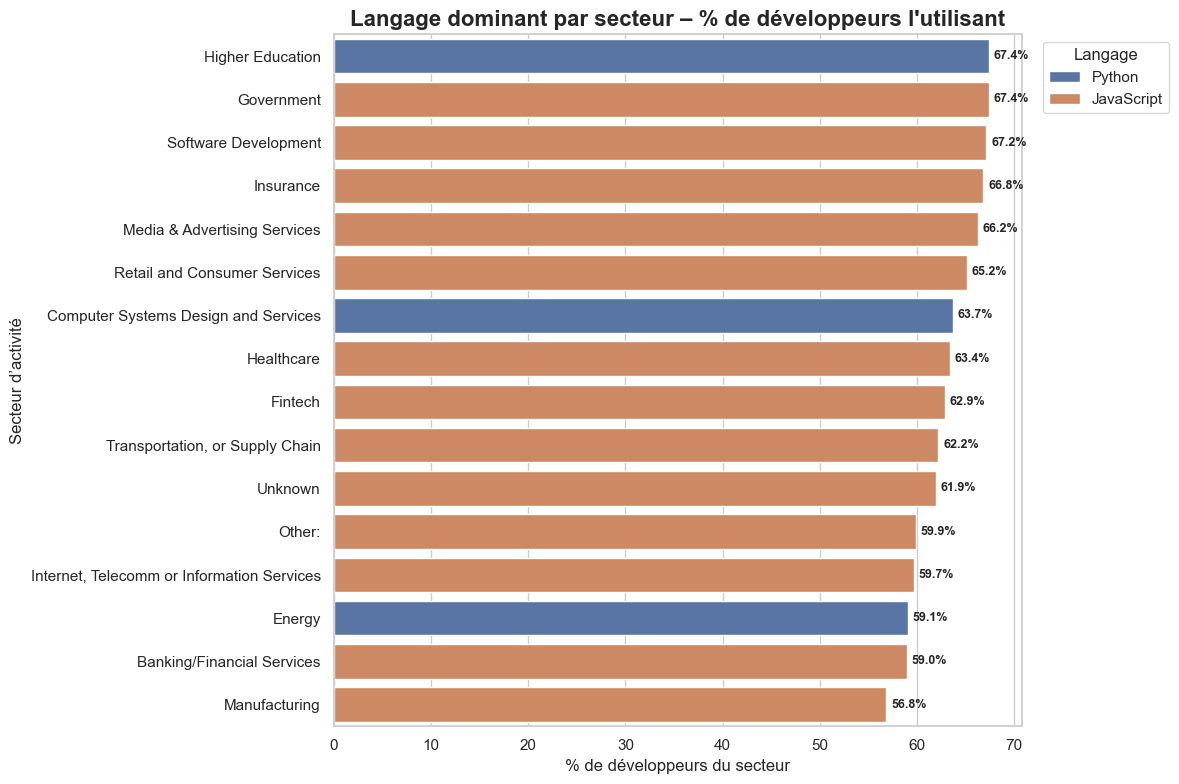

In [8]:
plt.figure(figsize=(12, 8))

plot_data = dominant_lang_pct_sorted  # déjà trié décroissant

ax = sns.barplot(
    data=plot_data,
    x="pct_devs",
    y="Industry",
    hue="LanguageHaveWorkedWith",
    dodge=False
)

for i, v in enumerate(plot_data["pct_devs"]):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9, fontweight="bold")

plt.title("Langage dominant par secteur – % de développeurs l'utilisant", fontsize=16, fontweight="bold")
plt.xlabel("% de développeurs du secteur")
plt.ylabel("Secteur d’activité")
plt.legend(title="Langage", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../Reports/Figures/Languages/08_languages_dominant_by_industry.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

- Dans la majorité des secteurs, **JavaScript** domine, en particulier dans le software, l’IT, le retail, le banking, la santé, le manufacturing et le secteur public.
- **Python** prend la tête dans l’enseignement supérieur, l’énergie et certains domaines techniques pointus (data, IA, automatisation).

En résumé :
- JavaScript est le langage transversal dominant, porté par l’écosystème web.
- Python domine les environnements orientés data, recherche, modèles et éducation.

### 4.4. Langages les plus utilisés selon le niveau d'expérience

In [9]:
# 1) Nombre de développeurs uniques par langage et niveau d'expérience
exp_lang = (
    df_lang
    .groupby(["ExperienceLevel", "LanguageHaveWorkedWith"])["ResponseId"]
    .nunique()
    .reset_index(name="count_devs")
)

# 2) Nombre total de développeurs par niveau d'expérience
exp_totals = (
    df_lang
    .groupby("ExperienceLevel")["ResponseId"]
    .nunique()
    .reset_index(name="total_devs_exp")
)

exp_totals

# 3) Merge + calcul du pourcentage
exp_lang = exp_lang.merge(exp_totals, on="ExperienceLevel", how="left")
exp_lang["pct_devs"] = (
    exp_lang["count_devs"] / exp_lang["total_devs_exp"] * 100
).round(2)

top5_exp_pct = (
    exp_lang
    .sort_values(["ExperienceLevel", "pct_devs"], ascending=[True, False])
    .groupby("ExperienceLevel")
    .head(5)
)

top5_exp_pct.head(10)



,ExperienceLevel,LanguageHaveWorkedWith,count_devs,total_devs_exp,pct_devs
22,debutant,JavaScript,10554,16064,65.70
36,debutant,Python,9410,16064,58.58
19,debutant,HTML/CSS,9123,16064,56.79
40,debutant,SQL,8131,16064,50.62
44,debutant,TypeScript,6796,16064,42.31
71,junior,JavaScript,12647,20366,62.10
68,junior,HTML/CSS,10933,20366,53.68
85,junior,Python,10795,20366,53.01
89,junior,SQL,9605,20366,47.16
93,junior,TypeScript,7654,20366,37.58


<Figure size 1200x600 with 0 Axes>

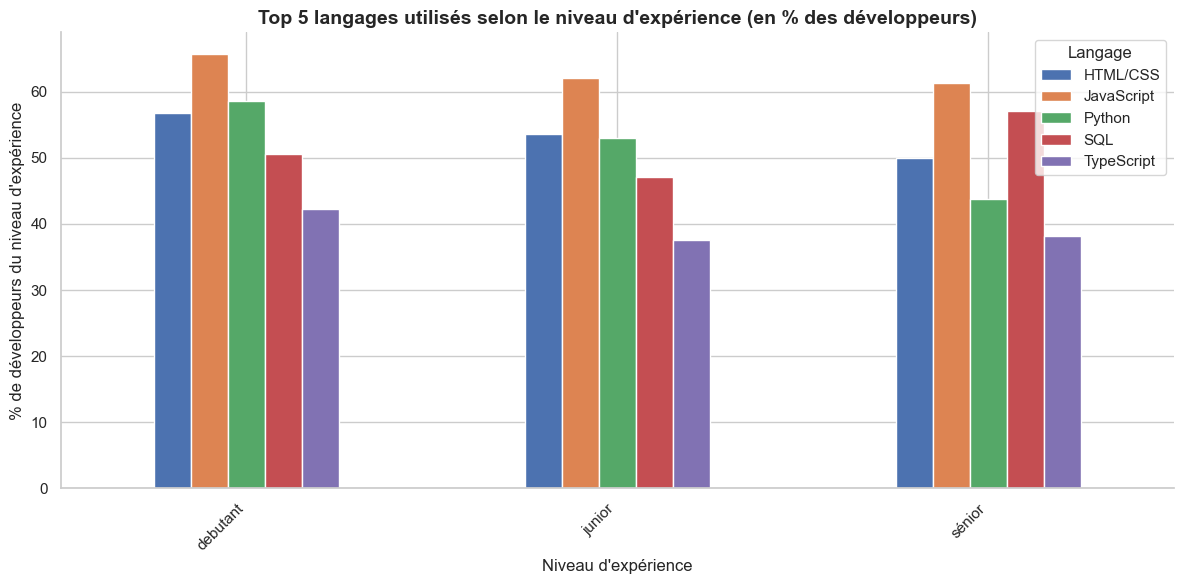

In [10]:
plt.figure(figsize=(12, 6))

pivot_exp_pct = (
    top5_exp_pct
    .pivot(index="ExperienceLevel", columns="LanguageHaveWorkedWith", values="pct_devs")
    .fillna(0)
)

pivot_exp_pct.plot(kind="bar", figsize=(12, 6))

plt.title("Top 5 langages utilisés selon le niveau d'expérience (en % des développeurs)", 
          fontsize=14, fontweight="bold")
plt.ylabel("% de développeurs du niveau d'expérience")
plt.xlabel("Niveau d'expérience")
plt.xticks(rotation=45, ha="right")

plt.legend(title="Langage")
sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Languages/08_languages_top5_by_experience.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

- Les **débutants** se concentrent sur JavaScript, HTML/CSS et Python, très présents dans les formations et tutoriels.
- Avec l’expérience, **SQL** devient beaucoup plus présent, logique dès qu’on touche aux systèmes d’entreprise et aux données structurées.


### 4.5. Langages utilisés par statut (Employed, Student, Retired, Independent)

In [11]:
statuses = ["Employed", "Student", "Retired", "Independent"]

dt_long = df_lang.melt(
    id_vars=["ResponseId", "LanguageHaveWorkedWith"],
    value_vars=statuses,
    var_name="Status",
    value_name="has_status"
)

dt_long = dt_long[dt_long["has_status"] == 1].drop(columns=["has_status"])

# NOMBRE DEV UNIque pqr status
status_totals = (
    dt_long.groupby("Status")["ResponseId"]
    .nunique()
    .reset_index(name="total_devs_status")
)

status_totals
# dev unique par status et lang
lang_stat = (
    dt_long.groupby(["Status", "LanguageHaveWorkedWith"])["ResponseId"]
    .nunique()
    .reset_index(name="count_devs")
)

lang_stat = lang_stat.merge(status_totals, on="Status", how="left")
lang_stat["pct_devs"] = (
    lang_stat["count_devs"] / lang_stat["total_devs_status"] * 100
).round(2)




top5_status_pct = (
    lang_stat
    .sort_values(["Status", "pct_devs"], ascending=[True, False])
    .groupby("Status")
    .head(5)
)




top5_status_pct[["Status","LanguageHaveWorkedWith","pct_devs"]].head()


,Status,LanguageHaveWorkedWith,pct_devs
22,Employed,JavaScript,62.19
40,Employed,SQL,53.54
19,Employed,HTML/CSS,51.25
36,Employed,Python,49.68
44,Employed,TypeScript,40.56


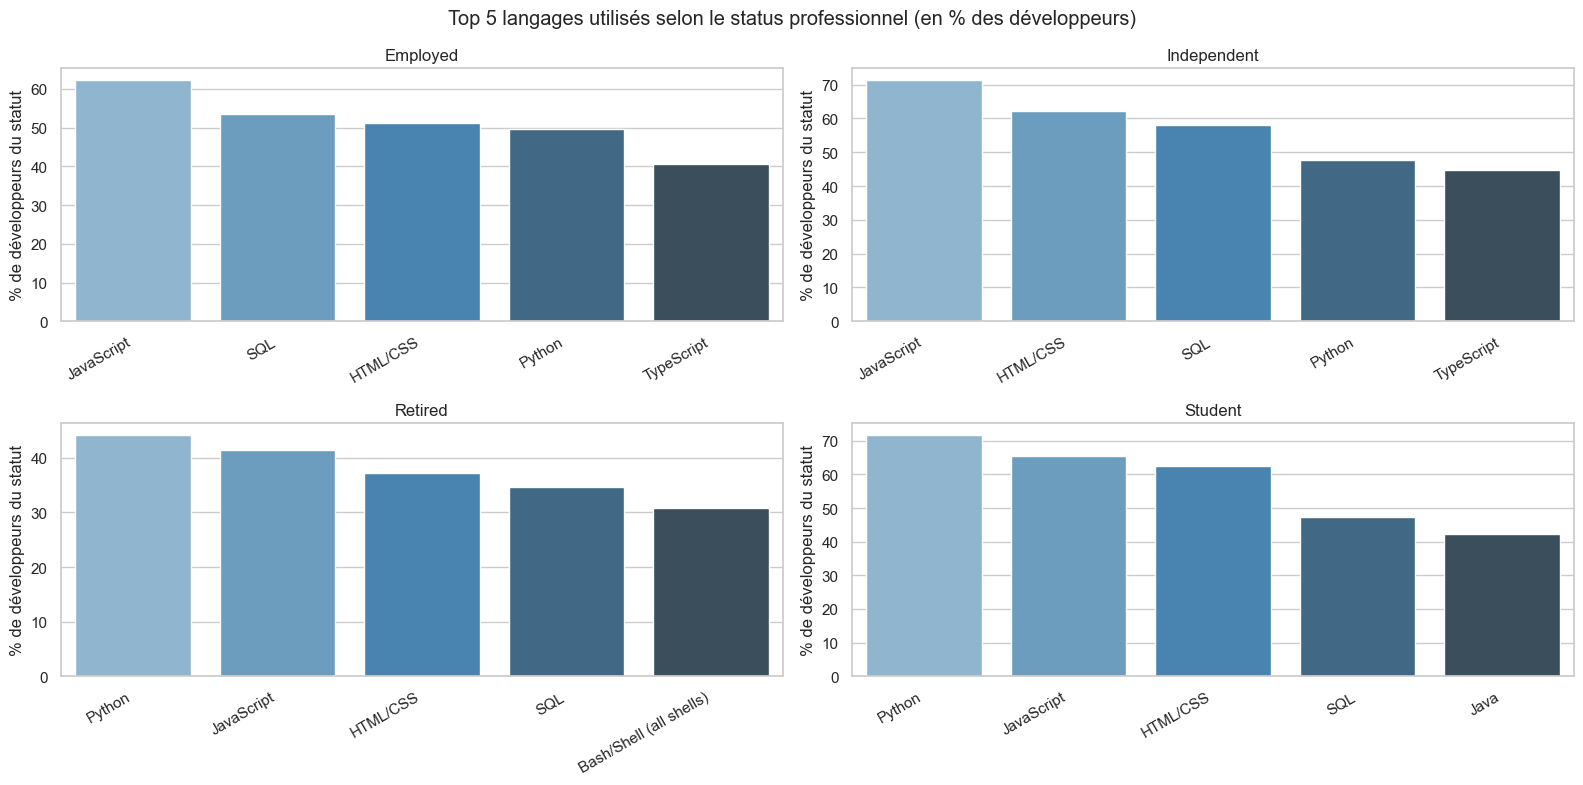

In [12]:
plt.figure(figsize=(16, 8))

statuses_unique = top5_status_pct["Status"].unique()

for i, status in enumerate(statuses_unique, 1):
    subset = top5_status_pct[top5_status_pct["Status"] == status]

    plt.subplot(2, 2, i)
    sns.barplot(
        data=subset,
        x="LanguageHaveWorkedWith",
        y="pct_devs",
        palette="Blues_d",
        hue="LanguageHaveWorkedWith",
        dodge=False,
        legend=False
    )

    plt.title(status)
    plt.ylabel("% de développeurs du statut")
    plt.xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.suptitle("Top 5 langages utilisés selon le status professionnel (en % des développeurs)")

plt.tight_layout()
plt.savefig("../Reports/Figures/Languages/08_languages_top5_by_status.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

- **Employed** et **Independent** sont très orientés **web** : JavaScript, SQL, HTML/CSS dominent.
- Les **Students** se distinguent par une forte présence de **Python**, cohérente avec la data, l’IA et l’apprentissage.
- Les **Retired** (échantillon plus réduit) restent centrés sur Python et les langages web, souvent par intérêt personnel ou poursuite d’activités techniques.

En bref : le web domine chez les pros, Python domine chez les apprenants, SQL reste la brique incontournable en entreprise.


### 4.6. Top 2 langages dominants par tranche d’âge

In [15]:
# Préparation des données par tranche d'âge
dt_age = df_lang[["Age", "LanguageHaveWorkedWith"]].dropna().copy()
dt_age["LanguageHaveWorkedWith"] = dt_age["LanguageHaveWorkedWith"].str.strip()

TOP_N = 2

age_lang_counts = (
    dt_age
    .groupby(["Age", "LanguageHaveWorkedWith"])
    .size()
    .reset_index(name="count")
)

top_per_age = (
    age_lang_counts
    .sort_values(["Age", "count"], ascending=[True, False])
    .groupby("Age")
    .head(TOP_N)
)

pivot = (
    top_per_age
    .pivot(index="Age", columns="LanguageHaveWorkedWith", values="count")
    .fillna(0)
)

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
    "Prefer not to say"
]
pivot_pct = pivot_pct.reindex([a for a in age_order if a in pivot_pct.index])


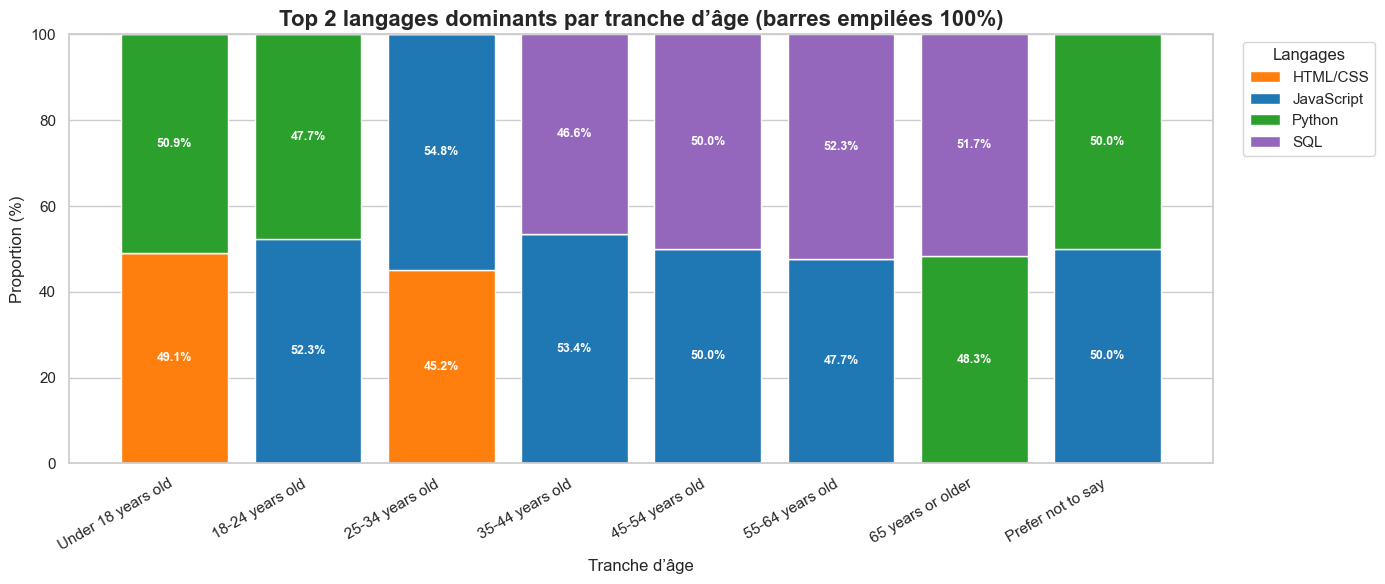

In [16]:
colors = {
    "JavaScript": "#1f77b4",
    "Python": "#2ca02c",
    "SQL": "#9467bd",
    "HTML/CSS": "#ff7f0e"
}
default_color = "#999999"

plt.figure(figsize=(14, 6))

bottom = [0] * len(pivot_pct)

for lang in pivot_pct.columns:
    values = pivot_pct[lang].values

    bars = plt.bar(
        pivot_pct.index,
        values,
        bottom=bottom,
        label=lang,
        color=colors.get(lang, default_color)
    )

    for i, (bar, pct) in enumerate(zip(bars, values)):
        if pct > 5:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[i] + pct / 2,
                f"{pct:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="white",
                fontweight="bold"
            )

    bottom = [a + b for a, b in zip(bottom, values)]

plt.title("Top 2 langages dominants par tranche d’âge (barres empilées 100%)",
          fontsize=16, fontweight="bold")
plt.ylabel("Proportion (%)")
plt.xlabel("Tranche d’âge")
plt.xticks(rotation=30, ha="right")

plt.legend(title="Langages", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../Reports/Figures/Languages/08_languages_top2_by_age.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

Les tranches d’âge les plus jeunes sont dominées par JavaScript, HTML/CSS et Python.
Les tranches plus âgées montrent une plus forte présence de SQL et de langages backend, ce qui colle avec des rôles plus orientés système, data et architecture.


## 5. Langages que les développeurs souhaitent utiliser (LanguageWantToWorkWith)

In [17]:
# On calcule les % par rapport au nombre total de répondants
dz = df[["ResponseId", "LanguageWantToWorkWith"]].dropna(subset=["LanguageWantToWorkWith"]).copy()

dz["LanguageWantToWorkWith"] = dz["LanguageWantToWorkWith"].str.split(";")
dz = dz.explode("LanguageWantToWorkWith")
dz["LanguageWantToWorkWith"] = dz["LanguageWantToWorkWith"].str.strip()
dz.reset_index(drop=True, inplace=True)

# Top 10 en %
dz_langage_pct = (
    dz["LanguageWantToWorkWith"]
    .value_counts()
    .head(10) * 100 / nb_repondants   # nb_repondants défini plus haut dans le notebook
).round(2)

dz_langage_pct


LanguageWantToWorkWith
Python                     39.35
JavaScript                 37.42
SQL                        35.57
HTML/CSS                   32.65
TypeScript                 32.10
Rust                       27.11
Go                         21.85
Bash/Shell (all shells)    21.84
C#                         20.47
C++                        16.78
Name: count, dtype: float64

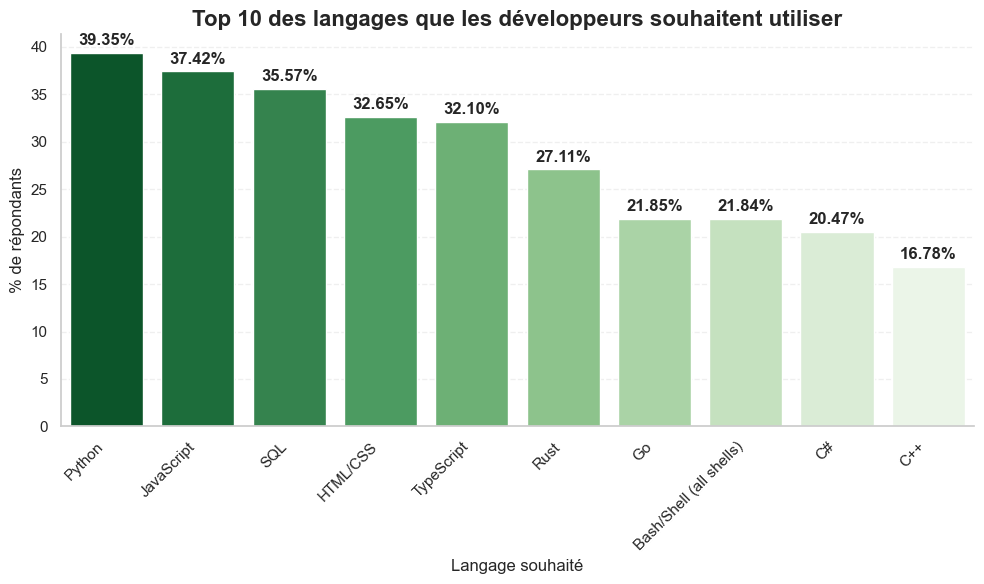

In [18]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=dz_langage_pct.index,
    y=dz_langage_pct.values,
    palette="Greens_r",
    hue=dz_langage_pct.index
)

# Labels au-dessus des barres en %
for i, v in enumerate(dz_langage_pct.values):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center", va="bottom", fontweight="bold")

plt.title("Top 10 des langages que les développeurs souhaitent utiliser",
          fontsize=16, fontweight="bold")

plt.xlabel("Langage souhaité", fontsize=12)
plt.ylabel("% de répondants", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Languages/08_languages_top10_wanted.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

Les développeurs privilégient clairement les langages :

- **modernes et polyvalents** : Python (data/IA), JavaScript/TypeScript (web), Go et Rust (performance, systèmes),
- **structurants** : SQL reste incontournable,
- **orientés cloud / DevOps** : Bash, C#.

La tendance va vers la **data**, le **web moderne**, la **performance** et le **cloud**.


## 6. Langages admirés par les développeurs (LanguageAdmired)

In [19]:
da = df[["ResponseId", "LanguageAdmired"]].dropna(subset=["LanguageAdmired"]).copy()

da["LanguageAdmired"] = da["LanguageAdmired"].str.split(";")
da = da.explode("LanguageAdmired")
da["LanguageAdmired"] = da["LanguageAdmired"].str.strip()
da.reset_index(drop=True, inplace=True)

# Top 10 en %
dh_langage_pct = (
    da["LanguageAdmired"]
    .value_counts()
    .head(10) * 100 / nb_repondants
).round(2)

dh_langage_pct


LanguageAdmired
JavaScript                 34.52
SQL                        32.96
Python                     32.61
HTML/CSS                   31.34
TypeScript                 25.63
Bash/Shell (all shells)    20.38
C#                         16.67
Java                       13.56
C++                        11.35
Rust                        9.78
Name: count, dtype: float64

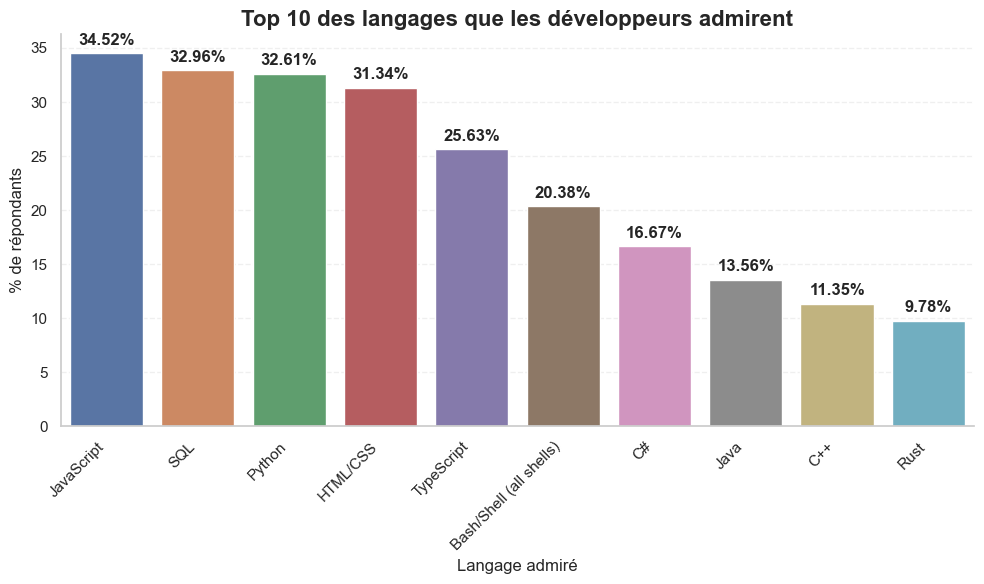

In [20]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=dh_langage_pct.index,
    y=dh_langage_pct.values,
    hue=dh_langage_pct.index
)

for i, v in enumerate(dh_langage_pct.values):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center", va="bottom", fontweight="bold")

plt.title("Top 10 des langages que les développeurs admirent",
          fontsize=16, fontweight="bold")

plt.xlabel("Langage admiré", fontsize=12)
plt.ylabel("% de répondants", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Languages/08_languages_top10_admired.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

Les développeurs admirent surtout :

- les langages **essentiels au web et aux données** : JavaScript, SQL, Python, HTML/CSS ;
- **TypeScript**, qui gagne en crédibilité sur les gros projets ;
- les langages historiques encore très présents en prod : C#, Java, C++ ;
- des langages plus récents comme **Rust**, appréciés pour leurs garanties de performance et de sécurité.

L’admiration suit globalement les langages qui combinent **impact**, **communauté forte** et **robustesse technique**.


## 7. Top 10 des langages offrant les salaires annuels les plus élevés

Pour chaque langage, on calcule le salaire annuel moyen des développeurs qui l’utilisent.
Ensuite, on exclut les langages avec moins de 500 répondants, car des effectifs trop faibles produisent des moyennes instables et très sensibles aux valeurs extrêmes.

Ce seuil permet de ne conserver que des langages appuyés par un échantillon suffisamment large pour être représentatif du marché.
Les salaires obtenus sont donc fiables, cohérents et réellement indicatifs des langages associés aux rémunérations les plus élevées.

In [21]:
top10_salary = (
    df_lang
    .groupby("LanguageHaveWorkedWith")["ConvertedCompYearly"]
    .agg(["mean", "count"])
    .query("count >= 500")  # seuil pour stabiliser les moyennes
    .sort_values("mean", ascending=False)
    .head(10)
)

top10_salary


,mean,count
LanguageHaveWorkedWith,,
Clojure,101086.034292,727
Erlang,98903.087169,510
Ruby,98729.259404,3090
Elixir,98567.150396,1220
Perl,96963.185596,1460
F#,94507.196423,505
Lisp,94378.395382,866
Scala,93750.212388,1525
Rust,89380.209402,7283


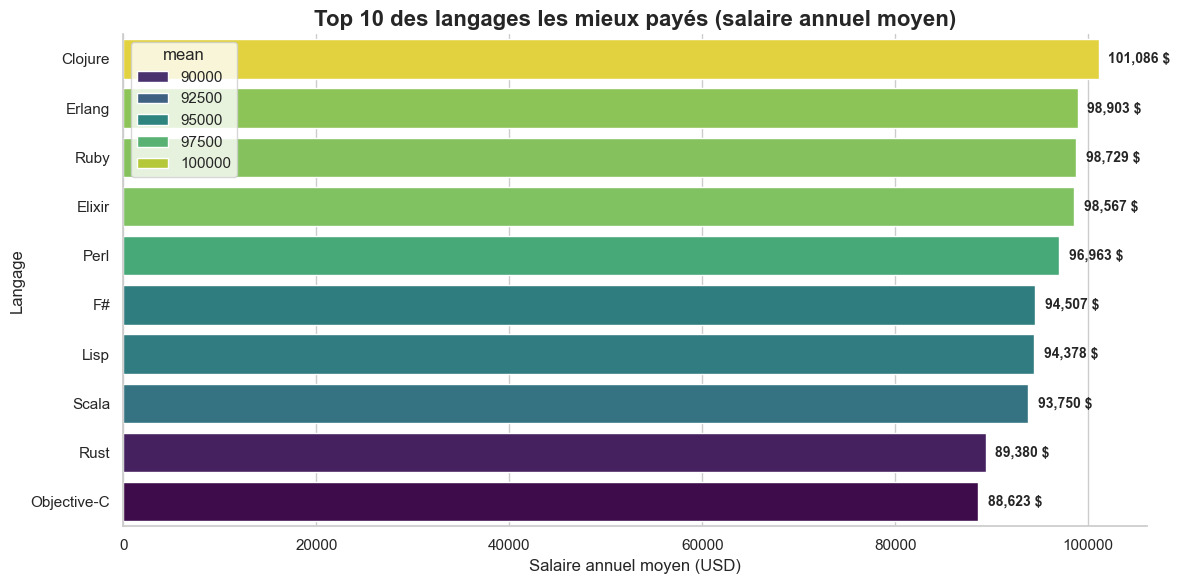

In [22]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top10_salary["mean"],
    y=top10_salary.index,
    palette="viridis",
    hue=top10_salary["mean"]
)

for i, v in enumerate(top10_salary["mean"]):
    plt.text(v + 1000, i, f"{v:,.0f} $", va="center", fontsize=10, fontweight="bold")

plt.title("Top 10 des langages les mieux payés (salaire annuel moyen)", fontsize=16, fontweight="bold")
plt.xlabel("Salaire annuel moyen (USD)")
plt.ylabel("Langage")
sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Languages/08_languages_salary_top10.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

- Les langages les mieux rémunérés sont souvent ceux utilisés dans des **niches techniques exigeantes** (backend critique, systèmes distribués, fintech, data pipelines).  
- La rémunération suit surtout la **rareté des compétences** et la **complexité des contextes d’usage**, plutôt que la simple popularité du langage.  
- Certains langages moins répandus mais très spécialisés restent associés à des salaires élevés, car ils sont clés dans des systèmes à forte valeur métier et à coût de migration élevé.


## 8. Résumé

Cette analyse des langages de programmation met en évidence plusieurs points clés :

- **Socle technologique dominant** : JavaScript, Python, SQL et HTML/CSS constituent la base commune de la plupart des développeurs, particulièrement dans les écosystèmes web et data.

- **Contexte métier marqué** : JavaScript reste le langage transversal par excellence, tandis que Python s’impose dans les domaines data, scientifiques et académiques.

- **Profils différenciés selon l’expérience** :  
  Les débutants se concentrent majoritairement sur le web et Python.  
  Les développeurs expérimentés utilisent davantage SQL, TypeScript et des langages orientés systèmes ou architectures complexes.  
  Les étudiants sont fortement orientés Python, ce qui reflète les formations actuelles.  
  Les professionnels privilégient un socle web associé à SQL, essentiel dans les environnements d’entreprise.

- **Effet générationnel** : les plus jeunes restent très orientés vers le web moderne et Python, tandis que les développeurs plus âgés se tournent davantage vers SQL et les stacks backend traditionnelles.

- **Intentions d’usage et admiration** : les développeurs montrent un intérêt marqué pour les langages modernes (Python, Rust, Go, TypeScript) et valorisent ceux offrant un écosystème robuste, de bonnes pratiques et une forte expressivité.

- **Rémunération** : les langages les mieux payés sont généralement ceux utilisés dans des niches spécialisées ou critiques, où les compétences sont rares et où la fiabilité des systèmes est essentielle.

Globalement, le paysage 2024 repose sur un tronc commun orienté web et data, complété par des langages de niche très bien rémunérés mais bien plus confidentiels dans leur adoption.
